---
title: "Boundary issues & support extension"
short_title: "03 · Boundary & support"
subtitle: "Why the empirical-CDF tails break the probit, how clipping and support extension fix it, and dequantising discrete inputs"
description: >
  The marginal step of RBIG inverts an empirical CDF through the probit. Outside
  the training range the CDF saturates at 0 or 1 and the probit diverges to ±∞;
  clipping keeps it finite but loses tail information, hurting the inverse. This
  notebook shows the failure, the bound-correction clip, support extension via
  pdf_extension (round-trip error 1.3 -> 1e-13), KDE tails, and dequantisation for
  discrete inputs — the numerical housekeeping that makes RBIG robust.
---

(sec-nb-rbig-03)=
# 03 — Boundary issues & support extension

RBIG's marginal step (Part 1 [00](../01_marginal_transforms/00_ecdf_histograms.ipynb))
maps a coordinate through $z = \Phi^{-1}(\hat F(x))$, where $\hat F$ is the
empirical CDF. That works beautifully *inside* the data range — but the empirical
CDF is **flat at $0$ below the smallest sample and at $1$ above the largest**, and
$\Phi^{-1}(0) = -\infty$, $\Phi^{-1}(1) = +\infty$. Any point in the tails — a new
test sample, or even a training point near the extremes — drives the transform
toward $\pm\infty$. This is the boundary problem, and it is exactly what produced
the tail round-trip error we saw in [notebook 00](00_rbig_loop.ipynb).

**What you will see**

- The **failure**: an out-of-support point maps to `nan`/$\pm\infty$ without bound
  correction.
- The **clip** (`bound_correct=True`): finite, but tail information is lost, so the
  inverse degrades in the tails.
- **Support extension** (`pdf_extension`): widen the CDF domain so the inverse is
  near-exact even in the tails (round-trip max error $1.3 \to 10^{-13}$).
- **Dequantisation**: add uniform noise so *discrete* inputs stop collapsing into a
  staircase under the CDF.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import rbig
from _style import style_ax

rng = np.random.default_rng(123)

# A skewed (Gamma) marginal: long right tail, so boundary effects are pronounced.
X = stats.gamma(a=4).rvs(size=(5000, 1), random_state=123)
print(f"training range: [{X.min():.2f}, {X.max():.2f}]")

training range: [0.17, 18.28]


## 1. The boundary problem

Take a point beyond the training range. Without bound correction the empirical CDF
reads exactly $1$ there and the probit diverges; with the default
`bound_correct=True`, `rbig` clips the CDF to $[\varepsilon, 1-\varepsilon]$ so the
output saturates at $\Phi^{-1}(1-\varepsilon) \approx 4.75$ instead of $+\infty$.

In [2]:
X_oos = np.array([[X.max() + 5.0]])           # 5 units beyond the largest sample

z_raw = rbig.MarginalGaussianize(bound_correct=False).fit(X).transform(X_oos)[0, 0]
z_clip = rbig.MarginalGaussianize(bound_correct=True, eps=1e-6).fit(X).transform(X_oos)[0, 0]
print(f"out-of-support point x = {X_oos[0, 0]:.2f}")
print(f"  bound_correct=False : z = {z_raw}   (probit diverges)")
print(f"  bound_correct=True  : z = {z_clip:.3f}   (clipped to Phi^-1(1-eps), finite)")

out-of-support point x = 23.28
  bound_correct=False : z = nan   (probit diverges)
  bound_correct=True  : z = 4.753   (clipped to Phi^-1(1-eps), finite)


The clip is the right *first* line of defence — it keeps the pipeline numerically
alive — and it is on by default. But clipping is lossy: every point past the
$\varepsilon$ quantile is mapped to the *same* saturated value, so the map is no
longer invertible there.

## 2. The cost of clipping: tail round-trip error

That saturation is precisely why the round-trip $x \to z \to x$ degraded in the
tails in notebook 00. We confirm it: the median round-trip error is tiny, but the
worst errors sit at the most extreme $|z|$.

round-trip error: median = 1.78e-04, max = 1.318
|z| at the 5 worst points: [2.83 2.76 3.29 3.43 3.72]  (all in the tails)


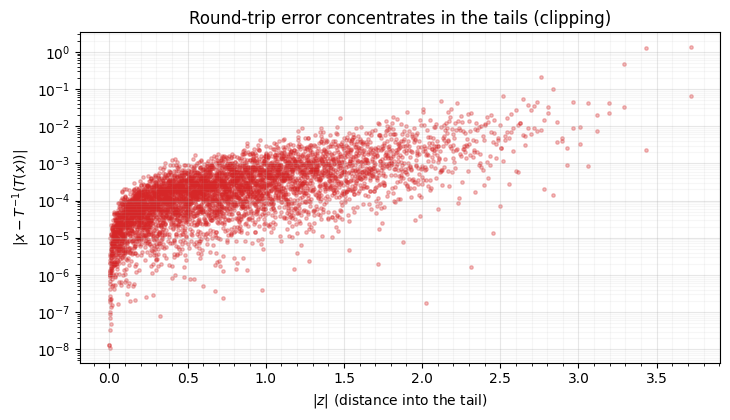

In [3]:
mg = rbig.MarginalGaussianize().fit(X)        # default: bound_correct=True
z = mg.transform(X)
X_rt = mg.inverse_transform(z)
err = np.abs(X - X_rt).ravel()
worst = np.argsort(err)[-5:]
print(f"round-trip error: median = {np.median(err):.2e}, max = {err.max():.3f}")
print(f"|z| at the 5 worst points: {np.round(np.abs(z.ravel()[worst]), 2)}  (all in the tails)")

fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.scatter(np.abs(z.ravel()), np.maximum(err, 1e-12), s=6, alpha=0.3, color="tab:red")
ax.set(title="Round-trip error concentrates in the tails (clipping)",
       xlabel=r"$|z|$ (distance into the tail)", ylabel=r"$|x - T^{-1}(T(x))|$",
       yscale="log")
style_ax(ax)
fig.tight_layout()

Inside $|z|\lesssim 2$ the round-trip is machine-accurate; past that it climbs by
orders of magnitude as the clip throws away tail resolution. For Gaussianization
*of* data this rarely matters, but for **generation** (inverting $z\sim\mathcal{N}(0,I)$,
which routinely draws $|z|>3$) it does — those are the smeared samples of
notebook 00.

## 3. Support extension fixes the tails

The cure is to **extend the support** before building the CDF: pad the quantile
domain beyond the observed range so the CDF has room to reach $0$ and $1$ smoothly
instead of saturating at the data extremes. `rbig.MarginalUniformize` exposes this
as `pdf_extension` (a percentage of the domain added on each side). Widening the
support collapses the tail round-trip error by orders of magnitude.

pdf_extension =    0%  ->  round-trip max error = 1.318e+00
pdf_extension =    5%  ->  round-trip max error = 1.066e-13
pdf_extension =   10%  ->  round-trip max error = 7.105e-14

MarginalKDEGaussianize: out-of-support z = 4.753 (smooth KDE tail, finite)


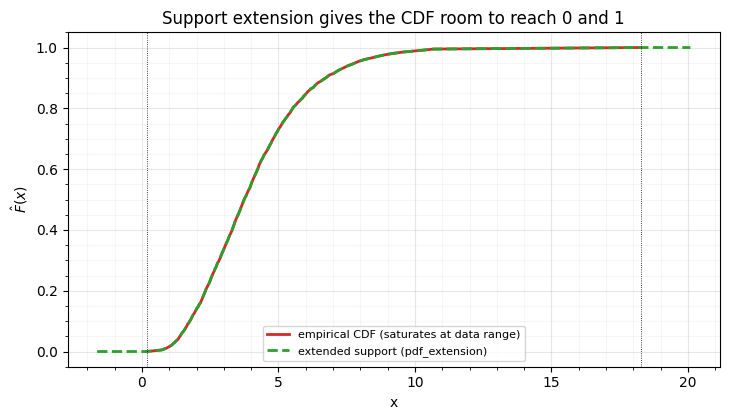

In [4]:
for ext in [0.0, 5.0, 10.0]:
    mu = rbig.MarginalUniformize(bound_correct=True, eps=1e-6, pdf_extension=ext).fit(X)
    rt = np.abs(X - mu.inverse_transform(mu.transform(X))).max()
    print(f"pdf_extension = {ext:4.0f}%  ->  round-trip max error = {rt:.3e}")

# KDE marginals are the smooth alternative: their tails extend naturally.
kde = rbig.MarginalKDEGaussianize(eps=1e-6).fit(X)
print(f"\nMarginalKDEGaussianize: out-of-support z = {float(kde.transform(X_oos)[0, 0]):.3f} "
      f"(smooth KDE tail, finite)")

# Picture the extension: empirical CDF saturates; extended CDF reaches 0/1 past the data.
q = np.percentile(X.ravel(), np.linspace(0, 100, 200))
ref = np.linspace(0, 1, 200)
dom = q.max() - q.min()
q_ext = np.hstack([q.min() - 0.1 * dom, q, q.max() + 0.1 * dom])
ref_ext = np.interp(q_ext, q, ref)

fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.plot(q, ref, color="tab:red", lw=2, label="empirical CDF (saturates at data range)")
ax.plot(q_ext, ref_ext, "--", color="tab:green", lw=2, label="extended support (pdf_extension)")
ax.axvline(X.min(), color="k", lw=0.6, ls=":"); ax.axvline(X.max(), color="k", lw=0.6, ls=":")
ax.set(title="Support extension gives the CDF room to reach 0 and 1",
       xlabel="x", ylabel=r"$\hat F(x)$")
ax.legend(fontsize=8); style_ax(ax)
fig.tight_layout()

With a 10 % extension the round-trip is back to machine precision: the inverse no
longer hits a saturated plateau. KDE marginals achieve a similar end differently —
their density (and CDF) extend *smoothly* just past the training range, so points
near the boundary get a graceful $z$ rather than a sharp plateau (a point far
outside, like the $+5$ above, still saturates at the $\varepsilon$ clip). Either
tool is what you want when you intend to **sample** from an RBIG model.

## 4. Dequantisation for discrete inputs

A different boundary pathology: **discrete** data. If $x$ takes only integer
values, many samples *tie*, the empirical CDF is a staircase, and the probit maps
every copy of a value to the *same* $z$ — the continuous Gaussianization collapses
onto a few atoms. The standard fix is **dequantisation**: add uniform noise
$u\sim\mathrm{Uniform}[0,1)$ to spread each integer over a unit interval before
Gaussianizing (the surjection revisited in Part 8).

discrete:     11 input levels -> 11 distinct z (staircase)
dequantised:  -> 5000 distinct z, std = 1.000


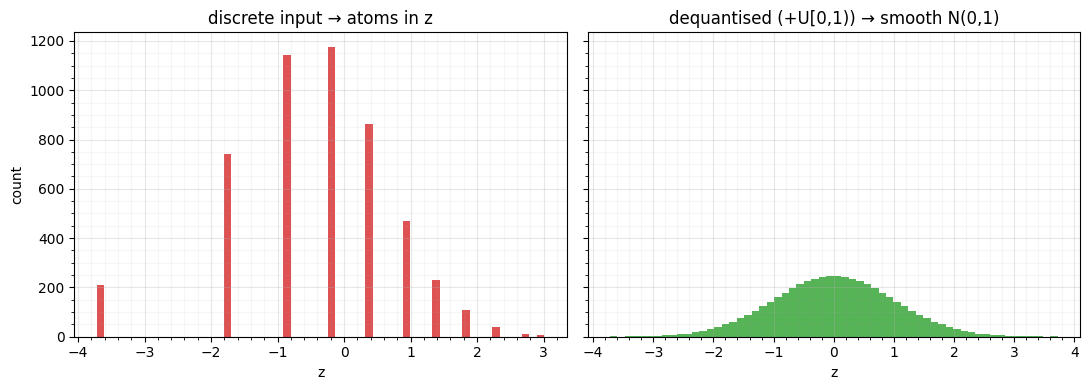

In [5]:
counts = rng.poisson(3, size=(5000, 1)).astype(float)        # discrete counts
z_disc = rbig.MarginalGaussianize().fit(counts).transform(counts)
deq = counts + rng.uniform(0, 1, counts.shape)               # dequantise
z_deq = rbig.MarginalGaussianize().fit(deq).transform(deq)

print(f"discrete:     {len(np.unique(counts))} input levels -> {len(np.unique(z_disc))} distinct z (staircase)")
print(f"dequantised:  -> {len(np.unique(z_deq))} distinct z, std = {z_deq.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
axes[0].hist(z_disc.ravel(), bins=60, color="tab:red", alpha=0.8)
axes[0].set(title="discrete input → atoms in z", xlabel="z", ylabel="count")
axes[1].hist(z_deq.ravel(), bins=60, color="tab:green", alpha=0.8)
axes[1].set(title="dequantised (+U[0,1)) → smooth N(0,1)", xlabel="z")
for ax in axes:
    style_ax(ax)
fig.tight_layout()

Without dequantisation the "Gaussianized" counts are a handful of spikes — useless
for a continuous flow. Adding sub-integer noise turns the staircase into a smooth
standard normal. (The noise is a stochastic surjection, with its own ELBO
bookkeeping; Part 8 treats it properly.)

## Recap

| issue | symptom | fix |
|---|---|---|
| empirical-CDF tails | $\Phi^{-1}(0/1) = \pm\infty$ | `bound_correct=True` clips to $[\varepsilon, 1-\varepsilon]$ |
| clipping is lossy | tail round-trip error blows up | `pdf_extension` (extend support) or KDE marginals |
| discrete inputs | ties → staircase / atoms in $z$ | dequantise: add $\mathrm{Uniform}[0,1)$ noise |

These are the numerical guardrails that make RBIG dependable end to end — and the
tail handling is what lets the generator of notebook 00 draw clean tail samples.

## Part 3 → Part 4

That completes **Iterative Gaussianization**: the RBIG loop (00), its convergence
and stopping rule (01), the rotation choices that set its speed (02), and the
boundary care that makes it robust (03). RBIG is *greedy and non-parametric* —
each layer fit once, never revisited. **Part 4 — Parametric Gaussianization
Flows** makes the whole stack *trainable*: the same rotation + marginal blocks, but
fit end-to-end by maximum likelihood — and that is where the **RBIG warm-start**
(using a greedy RBIG fit to initialise a trainable flow) naturally belongs.